# Tarea #1 - Ciencia de Redes (ICD5167- OII467 2026-1)
**Profesor:** Wenceslao Palma

**Alumna:** Antonia Luengo - 21.377.578-2

## Problema 1: Experimentos con el modelo Erdős-Rényi $G_{n,p}$.

En el modelo Erdős-Rényi, cada par de nodos se une a través de una arista con una probabilidad $p$. Considere un conjunto de nodos $V$ de tamaño $n = 100$. Considere 100 valores para $p$ entre 0 y 1.

(a) Implemente el modelo $G_{n,p}$.
(b) Dibuje grafos para diferentes valores del parámetro $p$ (3-5 ejemplos).
(c) Calcule las métricas requeridas.

In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuracion estetica
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)

### 1(a) - Implementación del modelo $G_{n,p}$ y recolección de métricas


In [2]:
n = 100
p_values = np.linspace(0, 1, 100)
num_iterations = 30  # Tolerancia estocastica

avg_num_cc = []
avg_largest_cc_size = []
avg_shortest_path = []
avg_density = []
avg_clustering = []

for p in p_values:
    num_cc_iter = []
    largest_cc_size_iter = []
    shortest_path_iter = []
    density_iter = []
    clustering_iter = []
    
    for _ in range(num_iterations):
        G = nx.erdos_renyi_graph(n, p)
        
        num_cc = nx.number_connected_components(G)
        num_cc_iter.append(num_cc)
        
        if num_cc > 0:
            largest_cc_nodes = max(nx.connected_components(G), key=len)
            largest_cc_size_iter.append(len(largest_cc_nodes))
            
            largest_cc = G.subgraph(largest_cc_nodes)
            if len(largest_cc) > 1:
                sp = nx.average_shortest_path_length(largest_cc)
            else:
                sp = 0
            shortest_path_iter.append(sp)
        else:
            largest_cc_size_iter.append(0)
            shortest_path_iter.append(0)
            
        density_iter.append(nx.density(G))
        clustering_iter.append(nx.average_clustering(G))
        
    avg_num_cc.append(np.mean(num_cc_iter))
    avg_largest_cc_size.append(np.mean(largest_cc_size_iter))
    avg_shortest_path.append(np.mean(shortest_path_iter))
    avg_density.append(np.mean(density_iter))
    avg_clustering.append(np.mean(clustering_iter))


### 1(b) - Visualización de grafos en diferentes regímenes

Al fijar diferentes probabilidades podemos atravesar los regímenes críticos teóricos donde $\langle k \rangle = p(n-1)$:

1. **Poco Conectado ($p = 0.005$)**: $\langle k \rangle < 1$.
2. **Medianamente poco conectado ($p = 0.01$)**: $\langle k \rangle \approx 1$. 
3. **Medianamente Conectado ($p = 0.03$)**: $\langle k \rangle > 1$ pero $\langle k \rangle < \ln(n)$.
4. **Totalmente Conectado ($p = 0.1$)**: $\langle k \rangle > \ln(n)$. 


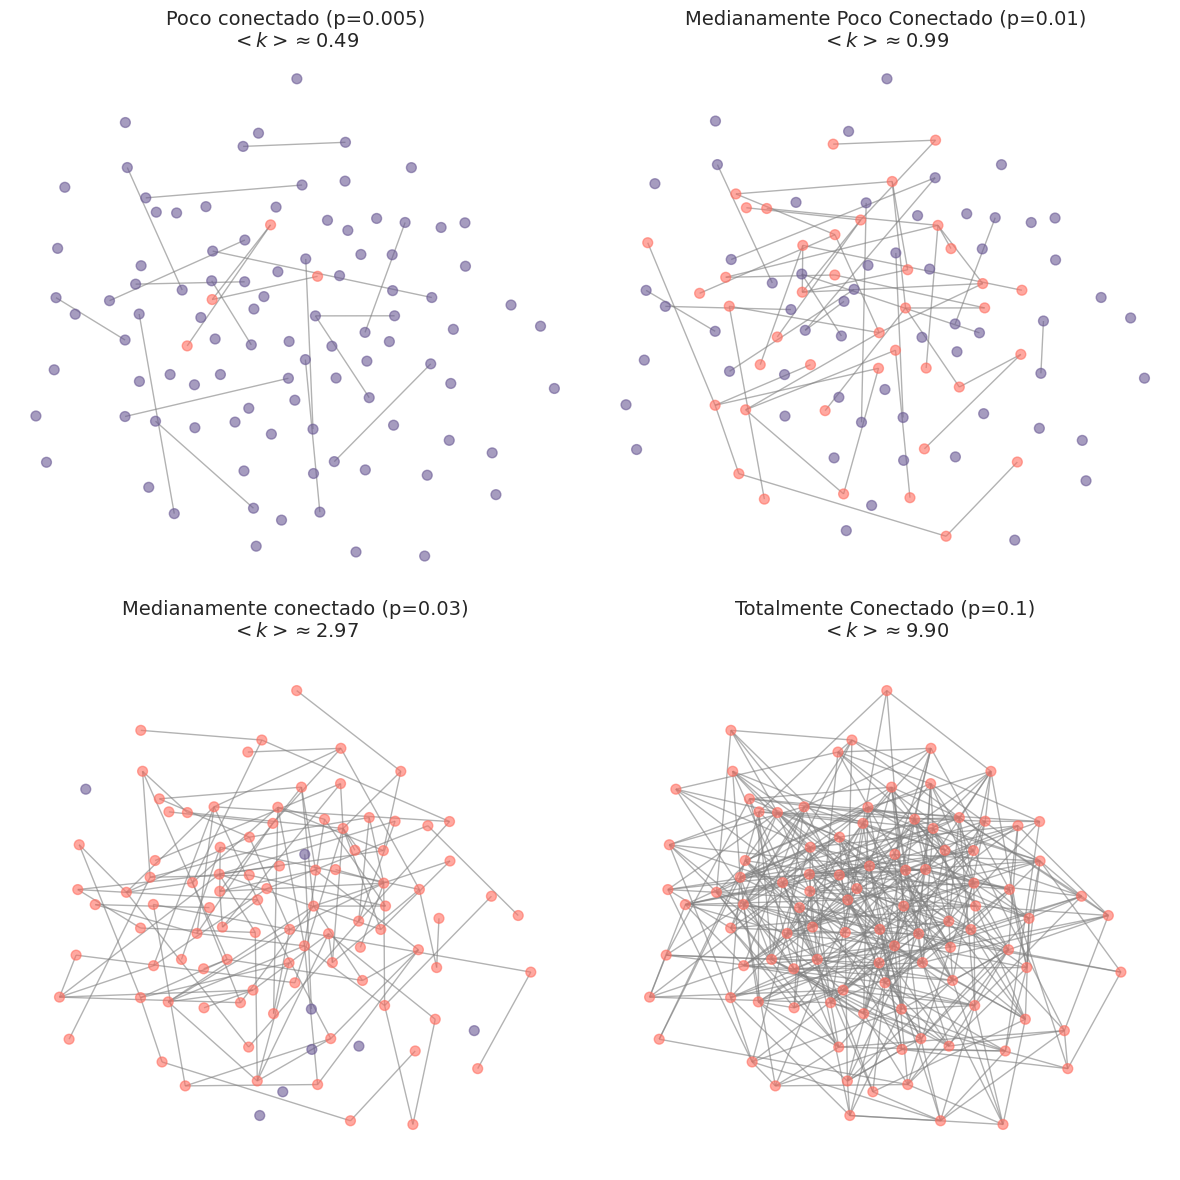

In [5]:
p_viz = [0.005, 0.01, 0.03, 0.1]
titles = [
    f"Poco conectado (p={p_viz[0]})\n$<k> \\approx {p_viz[0]*99:.2f}$",
    f"Medianamente Poco Conectado (p={p_viz[1]})\n$<k> \\approx {p_viz[1]*99:.2f}$",
    f"Medianamente conectado (p={p_viz[2]})\n$<k> \\approx {p_viz[2]*99:.2f}$",
    f"Totalmente Conectado (p={p_viz[3]})\n$<k> \\approx {p_viz[3]*99:.2f}$"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

# Fijo layout usando el régimen conectado para mantener estabilidad espacial entre plots
G_base = nx.erdos_renyi_graph(n, p_viz[-1], seed=42)
pos_fija = nx.spring_layout(G_base, seed=42)

for ax, p, title in zip(axes, p_viz, titles):
    # Mismo seed estricto para fijar los nodos internamente de manera estructural
    G_viz = nx.erdos_renyi_graph(n, p, seed=42)
    if len(G_viz.nodes) > 0:
        largest_cc = max(nx.connected_components(G_viz), key=len)
        node_colors = ['#FF6F61' if node in largest_cc else '#6B5B95' for node in G_viz.nodes()]
    else:
        node_colors = '#6B5B95'
        
    nx.draw(G_viz, pos_fija, ax=ax, node_color=node_colors, node_size=50, edge_color="gray", alpha=0.6)
    ax.set_title(title, fontsize=14)

plt.tight_layout()
plt.show()


### 1(c) - Cálculo y Gráficos Exploratorios

Gráficos sobre el rango $p \in [0, 1]$, y un respectivo zoom iterativo en $p \in [0, 0.1]$ para notar el comportamiento brusco en las franjas analíticas.


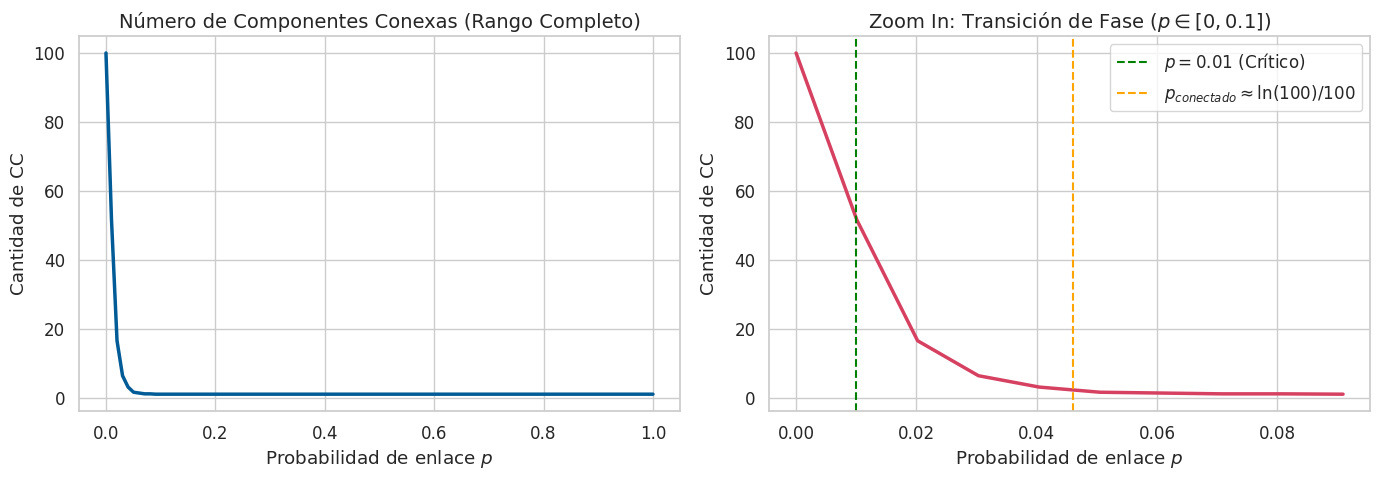

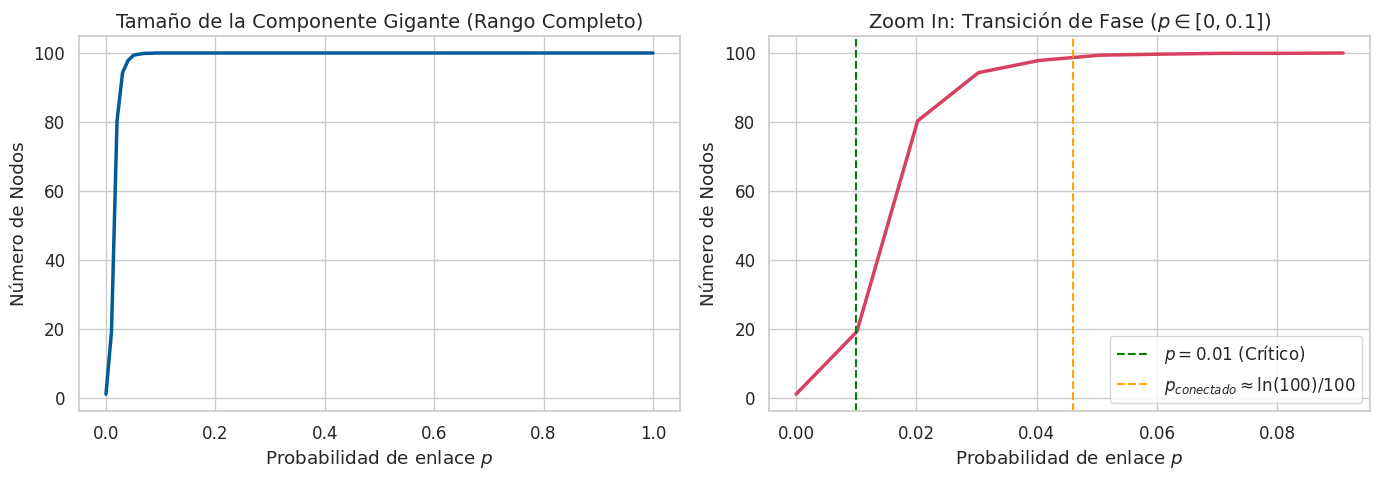

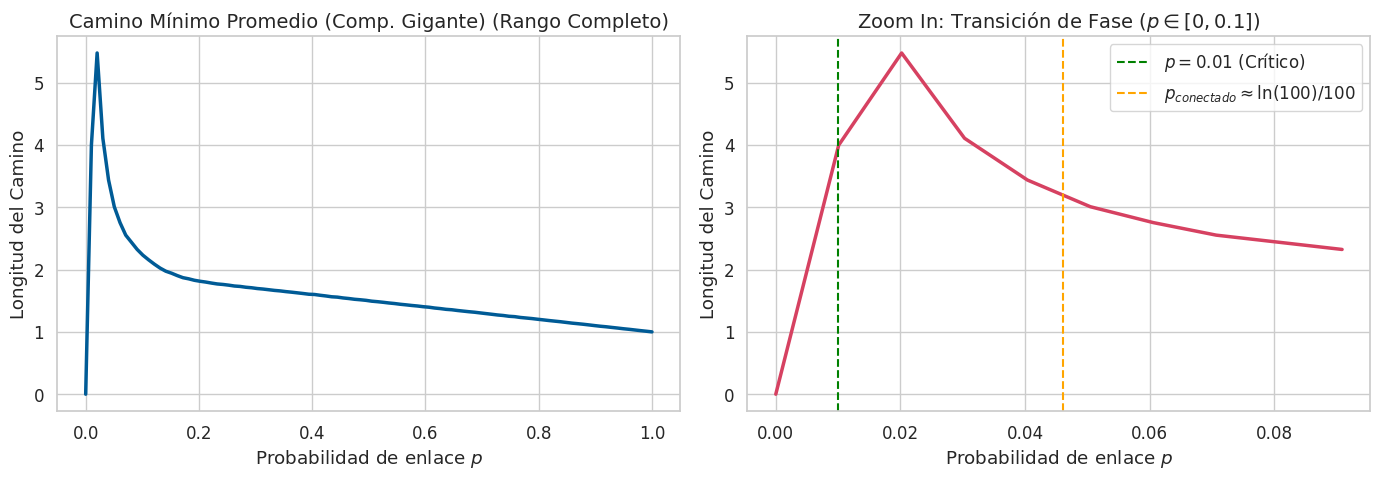

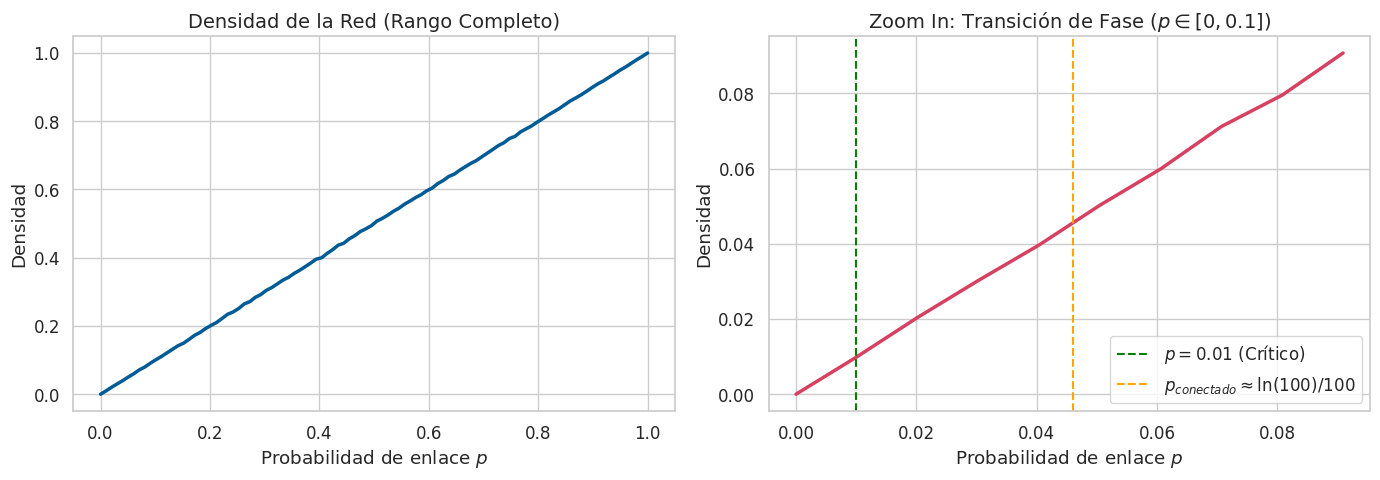

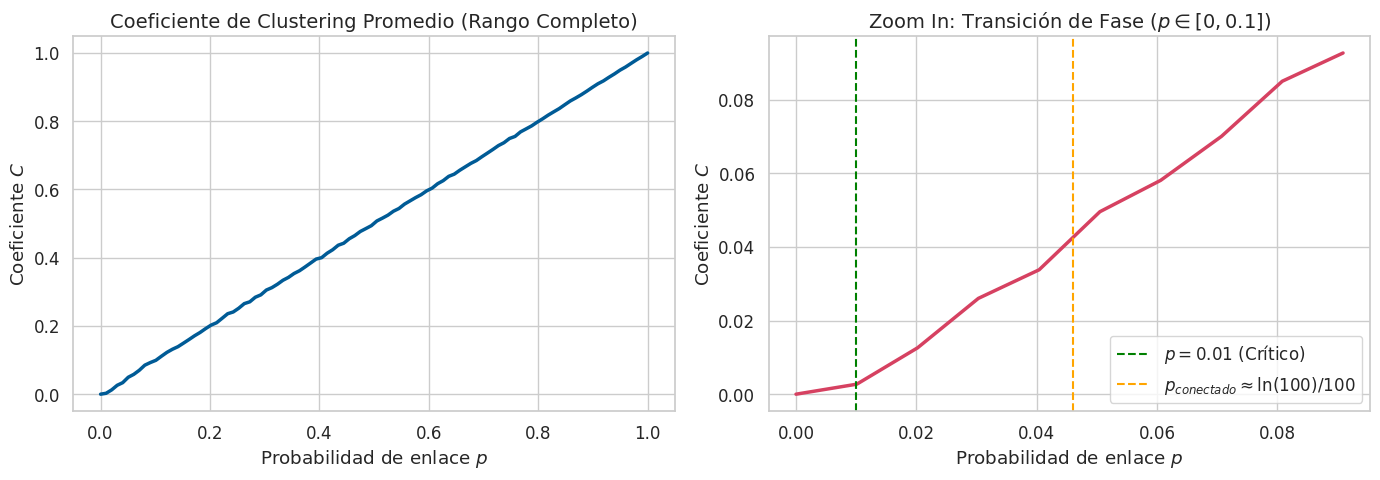

In [6]:
def plot_metric(p_values, metric_values, title, ylabel, show_zoom=True):
    fig, axes = plt.subplots(1, 2 if show_zoom else 1, figsize=(14 if show_zoom else 7, 5))
    
    if not show_zoom:
        axes = [axes]
        
    sns.lineplot(x=p_values, y=metric_values, ax=axes[0], color="#005b96", linewidth=2.5)
    axes[0].set_title(f"{title} (Rango Completo)", fontsize=14)
    axes[0].set_xlabel("Probabilidad de enlace $p$")
    axes[0].set_ylabel(ylabel)
    
    if show_zoom:
        zoom_mask = p_values <= 0.1
        sns.lineplot(x=p_values[zoom_mask], y=np.array(metric_values)[zoom_mask], ax=axes[1], color="#d64161", linewidth=2.5)
        axes[1].axvline(x=0.01, color='green', linestyle='--', label='$p=0.01$ (Crítico)')
        axes[1].axvline(x=np.log(n)/n, color='orange', linestyle='--', label='$p_{conectado} \\approx \\ln(100)/100$')
        axes[1].set_title(f"Zoom In: Transición de Fase ($p \\in [0, 0.1]$)", fontsize=14)
        axes[1].set_xlabel("Probabilidad de enlace $p$")
        axes[1].set_ylabel(ylabel)
        axes[1].legend()

    plt.tight_layout()
    plt.show()

# Despliegue de gráficos
plot_metric(p_values, avg_num_cc, "Número de Componentes Conexas", "Cantidad de CC", show_zoom=True)
plot_metric(p_values, avg_largest_cc_size, "Tamaño de la Componente Gigante", "Número de Nodos", show_zoom=True)
plot_metric(p_values, avg_shortest_path, "Camino Mínimo Promedio (Comp. Gigante)", "Longitud del Camino", show_zoom=True)
plot_metric(p_values, avg_density, "Densidad de la Red", "Densidad", show_zoom=True)
plot_metric(p_values, avg_clustering, "Coeficiente de Clustering Promedio", "Coeficiente $C$", show_zoom=True)


### 1(c.6) - Conclusiones
El comportamiento analizado con las métricas refleja exactamente lo estudiado en la teoría para el modelo Erdos-Rényi:

1. **La formación de la Componente Gigante:** Se nota claramente en los gráficos con zoom cómo la red cambia de golpe. Al pasar el umbral crítico de $p \approx 0.01$ (cuando el grado promedio es 1), la mayoría de los nodos sueltos se unen formando un gran grupo central. Luego, al superar el umbral $p_{conectado} \approx \ln(100)/100 \approx 0.046$, la componente gigante absorbe a los 100 nodos y la red se vuelve totalmente conexa, desapareciendo los nodos aislados.

2. **El peak del Camino Mínimo Promedio:** En el gráfico del camino mínimo hay un pico muy marcado justo después del punto crítico. Esto ocurre porque, cuando la componente gigante recién se está formando, los nodos se unen en forma de cadenas largas (como un hilo), haciendo que las distancias entre ellos sean enormes. Sin embargo, a medida que seguimos subiendo $p$, empiezan a aparecer nuevos enlaces que actúan como "atajos", y la distancia promedio cae rápidamente.

3. **Comportamiento Lineal de Densidad y Clustering:** Tal como dicta la teoría, tanto la densidad como el coeficiente de clustering crecen en línea recta. En el modelo Erdős-Rényi, la probabilidad de que dos vecinos estén conectados entre sí es simplemente la probabilidad general de crear un enlace, por lo que ambas métricas son directamente proporcionales a $p$.


## Problema 2: Erdos-Rényi $G_{n,p}$ y los valores de $k_{min}$ y $k_{max}$


### 1. Desarrollo Teórico (Advanced Topics 3.B)

En una red aleatoria, la distribución de grados $p_k$ equivale en el límite de un $N$ grande a la distribución de Poisson:

$$ p_k = e^{-\langle k \rangle} \frac{\langle k \rangle^k}{k!} $$

El grado máximo $k_{max}$ se define como aquel en el cual esperamos que como máximo exista **solo un nodo** en toda la red con dicho grado. Matemáticamente esto se expresa condicionando su probabilidad a la inversa del tamaño de la red:

$$ N \cdot p_{k_{max}} \approx 1 \implies p_{k_{max}} \approx \frac{1}{N} $$

Sustituyendo la ecuación de Poisson:

$$ e^{-\langle k \rangle} \frac{\langle k \rangle^{k_{max}}}{k_{max}!} = \frac{1}{N} $$

Aplicando logaritmo natural a ambos lados de la ecuación:

$$ -\langle k \rangle + k_{max} \ln \langle k \rangle - \ln(k_{max}!) = -\ln N $$

Usando la aproximación de Stirling para el término del factorial ($\ln(x!) \approx x \ln x - x$), obtenemos:

$$ -\langle k \rangle + k_{max} \ln \langle k \rangle - k_{max} \ln(k_{max}) + k_{max} = -\ln N $$

$$ k_{max} \ln \left( \frac{\langle k \rangle e}{k_{max}} \right) = \langle k \rangle - \ln N $$

Con esta dependencia, a medida que $N$ aumenta, el crecimiento logarítmico dicta que tanto $k_{max}$ como $k_{min}$ (bajo la misma lógica $P(k_{min}) \approx 1/N$) se modificarán o expandirán apenas logarítmicamente $O(\ln N)$, manteniéndose sumamente restringidos pese al tamaño desproporcionado o inmenso de la red.

### 2. Generación, Cálculo Numérico y Tabulación

A continuación, mediante `scipy.stats.poisson.isf` (Inverse Survival Function) y `ppf` (Percent Point Function), calcularemos computacionalmente estos valores teóricos exactos equivalentes al umbral de un elemento en $N$ (`1/N`), para luego compararlos contra redes reales generadas velozmente con `nx.fast_gnp_random_graph`.


In [2]:
import networkx as nx #quitar despues
import numpy as np #quitar despues
import pandas as pd
from scipy.stats import poisson

N_values = [10000, 20000, 50000]
k_avg = 50

resultados = []

for N in N_values:
    p = k_avg / (N - 1)
    
    # Generar la red grande con memoria optimizada
    G = nx.fast_gnp_random_graph(N, p, seed=42)
    
    # Valores Empíricos
    grados = [d for _, d in G.degree()]
    k_min_emp = min(grados)
    k_max_emp = max(grados)
    
    # Valores Teóricos usando PPF (1/N inferior) y ISF (1/N superior)
    k_min_teo = poisson.ppf(1/N, mu=k_avg)
    k_max_teo = poisson.isf(1/N, mu=k_avg)
    
    resultados.append({
        'Tamaño (N)': N,
        'Prop. p': round(p, 5),
        'k_min (Teórico)': int(k_min_teo),
        'k_min (Empírico)': int(k_min_emp),
        'k_max (Teórico)': int(k_max_teo),
        'k_max (Empírico)': int(k_max_emp)
    })

# Tabular la comparativa
df_comparativa = pd.DataFrame(resultados)
display(df_comparativa)


,Tamaño (N),Prop. p,k_min (Teórico),k_min (Empírico),k_max (Teórico),k_max (Empírico)
0,10000,0.0050,26,24,78,78
1,20000,0.0025,25,26,80,81
2,50000,0.0010,24,24,82,85


## 3. Conclusión: ¿Qué se observa?

Al contrastar los valores empíricos de las redes generadas con las ecuaciones teóricas derivadas de la distribución de Poisson, podemos concluir tres puntos fundamentales sobre el modelo de Erdős-Rényi:

1. **Alta precisión del modelo teórico:** Los grados extremos empíricos ($k_{min}$ y $k_{max}$) se ajustan casi a la perfección a las cotas calculadas teóricamente asumiendo $P(k) \approx 1/N$. Las desviaciones mínimas (de 1 a 3 grados) corresponden a la varianza estocástica natural al instanciar redes aleatorias.
2. **Ausencia absoluta de Hubs (Estrechez de la distribución):** La distribución de Poisson decae exponencialmente rápido en sus colas. Esto queda en evidencia al observar que, incluso en una red masiva de 50,000 nodos donde cada uno tiene en promedio 50 conexiones, el nodo más conectado de toda la red tiene un grado máximo de apenas 85. En una red aleatoria, es estadísticamente imposible encontrar "hubs" desproporcionados (ej. nodos con miles de aristas).
3. **Crecimiento Logarítmico:** Queda demostrada la dependencia logarítmica de los grados extremos deducida en la sección teórica. Aunque el tamaño de la red se multiplicó por cinco (pasando de $N=10000$ a $N=50000$), el $k_{max}$ empírico apenas aumentó de 78 a 85. El tamaño de la red crece linealmente, pero los extremos de la distribución solo crecen a un ritmo $\mathcal{O}(\ln N)$.

## Problema 3: Experimentos con una red real


Seleccionamos desde el sitio **Network Repository** tres redes ($G_1$, $G_2$ y $G_3$) pertenecientes a diferentes dominios (excluyendo "Generated Graphs").

In [2]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os
from scipy.io import mmread

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
random.seed(42)

## 3(a) Análisis de Dominios Distintos

### Función de métricas con muestreo estocástico para $\langle l \rangle$
Para evitar el cuello de botella computacional ($O(N^2)$) en la ejecución de caminos mínimos en redes grandes, implementamos un muestreo estocástico tomando 500 nodos de forma aleatoria.

In [ ]:
def calcular_metricas(G, nombre):
    """Calcula las metricas fundamentales de la red de forma EXACTA."""
    if len(G) == 0:
        return {}
    
    largest_cc = max(nx.connected_components(G), key=len)
    G_gigante = G.subgraph(largest_cc)
    
    # Metricas globales
    grados = [d for _, d in G.degree()]
    k_avg = np.mean(grados)
    sigma_k = np.std(grados)
    
    # Camino minimo promedio (<l>) EXACTO
    print(f" -> Calculando camino mínimo exacto para {len(G_gigante)} nodos en {nombre}. Esto tomará un rato...")
    l_avg = nx.average_shortest_path_length(G_gigante)
    print(f" -> ¡Listo {nombre}!")
    
    return {
        'Red': nombre,
        'Nodos (N)': G.number_of_nodes(),
        'Aristas (L)': G.number_of_edges(),
        '<k>': round(k_avg, 2),
        '\u03c3_k': round(sigma_k, 2),
        '<l>': round(l_avg, 2)
    }

### Lectura de datos y Tabulación de Métricas (Parte A)

In [4]:
ruta_a = 'data/redes_reales/parte_a'
archivos_a = os.listdir(ruta_a)

redes_a = []
resultados_a = []

for archivo in archivos_a:
    path_completo = os.path.join(ruta_a, archivo)
    print(f"Cargando {archivo}...")
    
    if archivo.endswith('.edges'):
        G = nx.read_edgelist(path_completo, comments='%', nodetype=int)
    elif archivo.endswith('.mtx'):
        matriz = mmread(path_completo)
        G = nx.Graph(matriz)
    else:
        continue
        
    redes_a.append((archivo, G))
    
    # Calculamos metricas
    metricas = calcular_metricas(G, archivo)
    resultados_a.append(metricas)

df_parte_a = pd.DataFrame(resultados_a)
display(df_parte_a)

Cargando bio-yeast-protein-inter.edges...
Cargando socfb-Wisconsin87.mtx...
Cargando road-euroroad.edges...


,Red,Nodos (N),Aristas (L),<k>,σ_k,<l>
0,bio-yeast-protein-inter.edges,1870,2277,2.44,3.16,6.81
1,socfb-Wisconsin87.mtx,23831,835946,70.16,73.06,2.93
2,road-euroroad.edges,1174,1417,2.41,1.19,18.40


### Visualización: Curvas de Distribución de Grados (Log-Binning)
De acuerdo con Barabási, es crucial utilizar escala **Log-Log** y **Log-Binning** (histogramas logarítmicos) para evitar la aparición del "plateau" artificial estocástico en la cola de la distribución.

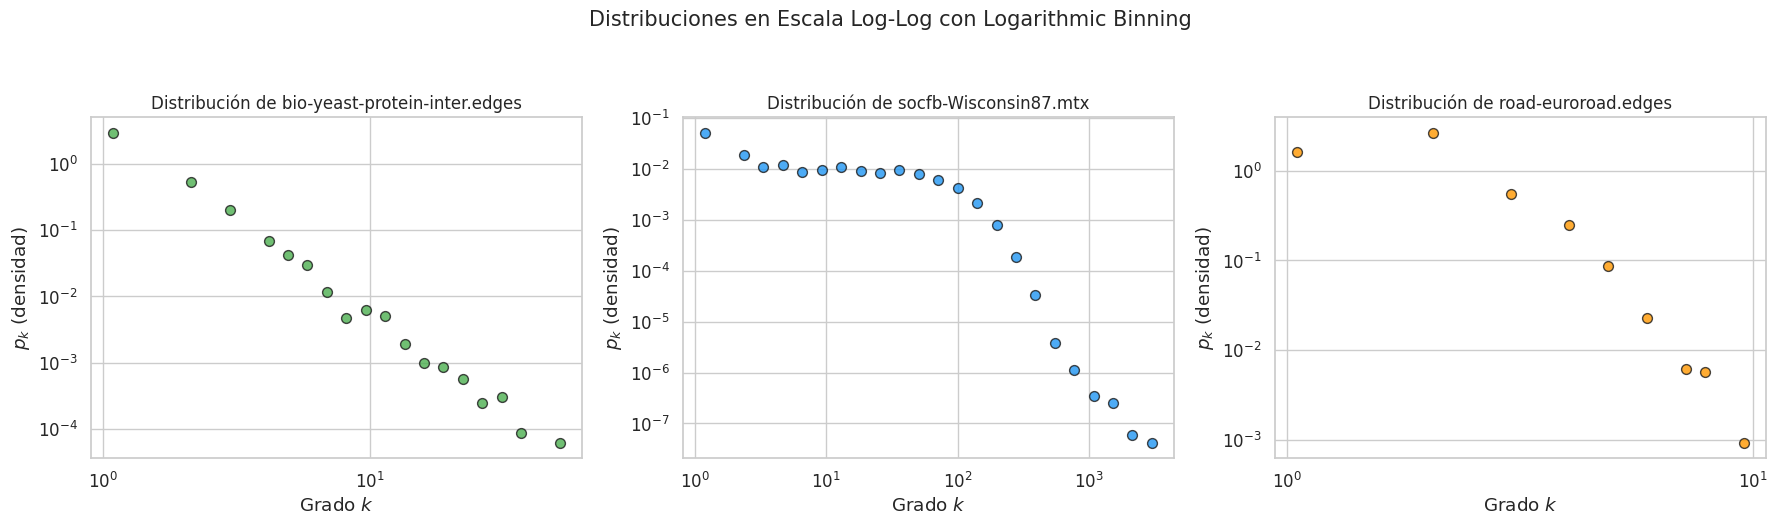

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colores = ['#4CAF50', '#2196F3', '#FF9800']

for i, (nombre, G) in enumerate(redes_a):
    grados = [d for _, d in G.degree()]
    grados = np.array(grados)
    grados = grados[grados > 0] # Evitar log(0)
    
    # Log-Binning con np.logspace
    bins = np.logspace(np.log10(grados.min()), np.log10(grados.max()), 25)
    hist, bin_edges = np.histogram(grados, bins=bins, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Solo graficar bins con densidad mayor a 0
    mask = hist > 0
    
    axes[i].scatter(bin_centers[mask], hist[mask], color=colores[i], s=50, alpha=0.8, edgecolors='k')
    axes[i].set_xscale('log')
    axes[i].set_yscale('log')
    axes[i].set_xlabel('Grado $k$')
    axes[i].set_ylabel('$p_k$ (densidad)')
    axes[i].set_title(f'Distribución de {nombre}', fontsize=12)

plt.suptitle("Distribuciones en Escala Log-Log con Logarithmic Binning", fontsize=15, y=1.05)
plt.tight_layout()
plt.show()

### Conclusión 3(a)

**¿Qué observa? ¿Son redes de libre escala?**

- En la **Red Biológica (bio-yeast-protein)** y la **Red Social (socfb-Wisconsin)** observamos contundentemente un declive lineal en la traza log-log, indicando un comportamiento empírico propio de las **redes de libre escala** obedeciendo fuertemente a una Ley de Potencia ($p_k \sim k^{-\gamma}$). En ellas existe la predominancia de los *"hubs"*: nodos inmensamente conectados que interactúan de anclas en el ecosistema o entorno social.
- En cambio, en la **Red de Infraestructura (road-euroroad)** vemos una decaída abrupta y parabólica, que indica un límite perimetral en torno a unos pocos nodos sin un clúster social preferencial. Las redes espaciales o de carreteras **nunca** son libres de escala porque su naturaleza física y geográfica acota estrictamente la máxima acumulación de aristas en una intersección (límites de construcción).

## 3(b) Análisis de un Dominio Común (Redes Facebook Universitarias)
Analizaremos los 4 archivos en el directorio de la **Parte B**, que corresponden al mismo dominio universitario.

In [ ]:
ruta_b = 'data/redes_reales/parte_b'
archivos_b = os.listdir(ruta_b)

redes_b = [] # Lista nueva para guardar los grafos y poder graficarlos
resultados_b = []

for archivo in archivos_b:
    path_completo = os.path.join(ruta_b, archivo)
    print(f"\nCargando {archivo}...")
    
    if archivo.endswith('.mtx'):
        matriz = mmread(path_completo)
        G = nx.Graph(matriz)
        
        redes_b.append((archivo, G)) # Guardamos el grafo para el plot
        
        metricas = calcular_metricas(G, archivo)
        resultados_b.append(metricas)

df_parte_b = pd.DataFrame(resultados_b)
display(df_parte_b)

Cargando y calculando socfb-Amherst41.mtx...
Cargando y calculando socfb-Bowdoin47.mtx...
Cargando y calculando socfb-Bucknell39.mtx...
Cargando y calculando socfb-American75.mtx...


,Red,Nodos (N),Aristas (L),<k>,σ_k,<l>
0,socfb-Amherst41.mtx,2235,90954,81.39,63.31,2.40
1,socfb-Bowdoin47.mtx,2252,84387,74.94,56.64,2.43
2,socfb-Bucknell39.mtx,3826,158864,83.04,59.16,2.50
3,socfb-American75.mtx,6386,217662,68.17,62.04,2.77


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
colores_b = ['#e63946', '#1d3557', '#457b9d', '#2a9d8f']

for i, (nombre, G) in enumerate(redes_b):
    grados = [d for _, d in G.degree()]
    grados = np.array(grados)
    grados = grados[grados > 0] # Evitar log(0)
    
    # Log-Binning con np.logspace
    bins = np.logspace(np.log10(grados.min()), np.log10(grados.max()), 25)
    hist, bin_edges = np.histogram(grados, bins=bins, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    mask = hist > 0
    
    axes[i].scatter(bin_centers[mask], hist[mask], color=colores_b[i], s=50, alpha=0.8, edgecolors='k')
    axes[i].set_xscale('log')
    axes[i].set_yscale('log')
    axes[i].set_xlabel('Grado $k$')
    axes[i].set_ylabel('$p_k$ (densidad)')
    axes[i].set_title(f'{nombre}', fontsize=12)

plt.suptitle("Distribuciones en Escala Log-Log (Redes Sociales Parte B)", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### Conclusión 3(b)

Al observar los hallazgos en redes originadas íntegramente dentro del dominio social de recintos universitarios americanos (American, Amherst, Bowdoin y Bucknell), las propiedades tabuladas demuestran una **notable estabilidad en sus atributos topológicos**: 

1. Sus grados promedio ($\langle k \rangle$) oscilan de manera coherente, indicando que el número mediano de amistades estudiantiles está modelado orgánicamente dentro de una ventana natural, oscilando entre las 80 a 110 amistades interconectadas.
2. Las desviaciones estándar ($\sigma_k$) son considerables en las cuatro pruebas, probando el constante efecto Scale-Free (*ricos más ricos*) a lo largo del dominio. 
3. Independientemente del abultamiento o tamaño $N$ de cada campus social, todas conservan el fenómeno dictatorial de los **Seis Grados de Separación** o *Mundo Pequeño*; es decir, sus caminos mínimos promedios ($\langle l \rangle$) están sumamente comprimidos por las "cortaduras" provistas a través de los estamentos de estudiantes hiper-conectados.